## Build Bernstein-Vazirani Algorithm in QpiAI Explorer Lab on Amazon Braket

In [1]:
#install amazon braket
%pip install amazon-braket-sdk

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313.7/313.7 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.0/224.0 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.7/191.7 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.2/139.2 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.0/377.0 kB 12.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 539.8/539.8 kB 12.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.2/117.2 kB 10.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 10.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.7/82.7 kB 4.5 MB/s eta 0:00:00
  Created wheel for antlr4-python3-runtime: filename=antlr4_python3_runtime-4.9.2-py3-none-any.whl size=144548 sha256=a952815e67d0d55490e76

In this tutorial, we will build a quantum circuit to implement the Bernstein-Vazirani algorithm using braket SDK to find a hidden bit string. After building the circuit, we will run it on QpiAI Explorer Lab using Amazon braket.

In [2]:
#Create general imports
import braket
import numpy as np

# Create AWS imports:
from braket.circuits import Circuit
from braket.devices import Device
from braket.devices import LocalSimulator
import matplotlib.pyplot as plt

### The Bernstein-Vazirani Algorithm

Given a Black box which implements the function $f(x)=0$ or $1$, where $x=x_0,x_1,\ldots,x_n$. Now, unlike the Deutsch-Jozsa Algorithm the function $f$ instead of being constant or balanced, is implemented as $f(x)=s.x (\mod 2)$. Our goal is to determine the bit string $s$.

A classical solution would require $n$ queries to reveal each of the bit values ($0$ or $1$) of $s$. Whereas, the Bernstein-Vazirani algorithm allows us to reveal the hidden string with just one query to the oracle with 100% chance. This algorithm is an extension of the Duetsch-Jozsa algorithm. We will briefly review the structure of the Bernstein-Vazirani algorithm and then the steps involved in building the circuit to find a hidden string for the case of two qubits.

Structure of the Berntsein-Vazirani algorithm

1. **Initializing the qubits**: The number of digits in the hidden string translate into the number of qubits required to find the hidden string. Suppose we have a hidden string '01', the two qubits are required to initialize the qubits and construct a circuit. For the implementation, we start with all the qubits at $|0\rangle$.

2. **Hadamard**: Now apply a Hadamard Gate on all qubits to achieve a uniform superposition of states. For the two qubit case, we have a equal superposition of $|00\rangle,|10\rangle,|01\rangle, \text{and}, |11\rangle$ states.


3. **Oracle query**: The oracle in Berstein-Vazirani algorithm performs the operation $|x\rangle \rightarrow (-1)^{f(x)}|x\rangle $ where $|x\rangle=|x_0x_1\ldots x_{n-1}\rangle$. This is implemented in the circuit using a CNOT gate on the state $|x\rangle|-\rangle$, with $|-\rangle$ as the target qubit and $|x\rangle$ as the control qubit.

4. **Hadamard**: Apply hadamard on all the qubits again. It transforms the qubits from $|+\rangle$ to $|0\rangle$ for $s_i=0$ and $|-\rangle$ to $|1\rangle$ for $s_i=1$.

5. **Results**: To find the hidden string 's', we make a computational basis measurement.

We will build functions to implement the circuits for performing a search using the Bernstein-Vazirani algorithm on Amazon braket

In [3]:
# define the Bernstein Vazirani circuit for a given hidden string which takes the string as the input and returns
# the corresponding circuit required to implement the Bernstein-Vazirani algorithm

def bv_circuit(hidden_string: str) -> Circuit:

    num_qubits = len(hidden_string)

    # Initialize all the qubits in |0> state
    bv_circuit = Circuit()

    # Create an extra qubit in |-> state to be used later for implementing the oracle
    bv_circuit.h(num_qubits)
    bv_circuit.z(num_qubits)

    # Apply Hadamard on all the qubits in |0> state
    bv_circuit.h(range(num_qubits))

    # Implementing the Oracle
    for q in range(num_qubits):
        if hidden_string[q] == "0":
            bv_circuit.i(q)
        else:
            bv_circuit.cnot(q, num_qubits)

    # Apply Hadamard on all the qubits once again
    bv_circuit.h(range(num_qubits))

    # Get maximum probability qubit in the superposition which actually corresponds to the hidden bit-string
    bv_circuit.probability(range(num_qubits))
    return bv_circuit


In [4]:
def run_bv_circuit(circ):

    # get number of qubits
    num_qubits = len(hidden_string)

    # specify desired results_types
    circ.probability()

    # run the circuit
    task = device.run(circ, shots=1000)


    # get result
    result = task.result()

    # get output probabilities
    probs_values = result.values[0]


    # get measurement results
    measurement_counts = result.measurement_counts

    # bitstrings
    format_bitstring = '{0:0' + str(num_qubits) + 'b}'
    bitstring_keys = [format_bitstring.format(ii) for ii in range(2**num_qubits)]

    # plot probabalities
    plt.bar(bitstring_keys, probs_values);
    plt.xlabel('bitstrings');
    plt.ylabel('probability');
    plt.xticks(rotation=90);

    hidden = [[bitstring_keys[i],probs_values[i]] for i in range(0,2**num_qubits)]

    return hidden

### Test the Bernstein Vazirani circuit

We will now run the circuit to implement Berstein-Vazirani algorithm to find the hidden string

In [5]:
device = LocalSimulator()


T  : │  0  │  1  │  2  │  3  │ Result Types  │
      ┌───┐ ┌───┐ ┌───┐       ┌─────────────┐ 
q0 : ─┤ H ├─┤ I ├─┤ H ├───────┤ Probability ├─
      └───┘ └───┘ └───┘       └──────┬──────┘ 
      ┌───┐             ┌───┐ ┌──────┴──────┐ 
q1 : ─┤ H ├─────────●───┤ H ├─┤ Probability ├─
      └───┘         │   └───┘ └─────────────┘ 
      ┌───┐ ┌───┐ ┌─┴─┐                       
q2 : ─┤ H ├─┤ Z ├─┤ X ├───────────────────────
      └───┘ └───┘ └───┘                       
T  : │  0  │  1  │  2  │  3  │ Result Types  │
[['00', 0.0], ['01', 1.0], ['10', 0.0], ['11', 0.0]]


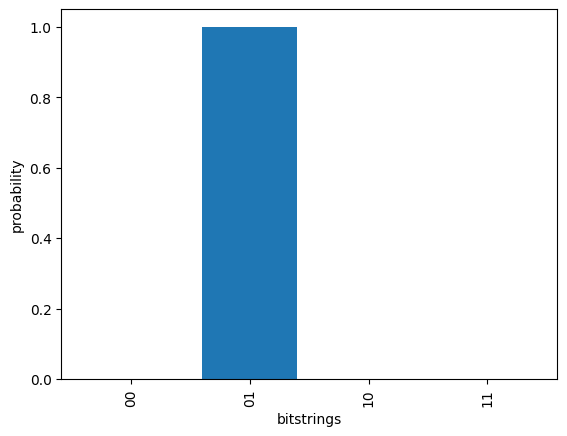

In [6]:
# Implement BV circuit to find the hidden string '01'

hidden_string = "01"

# get Bernstein-Vazirani circuit
circ = bv_circuit(hidden_string)

# print circuit
print(circ)

solution = run_bv_circuit(circ)
print(solution)

T  : │  0  │  1  │     2     │  3  │  4  │ Result Types  │
      ┌───┐                   ┌───┐       ┌─────────────┐ 
q0 : ─┤ H ├─────────●─────────┤ H ├───────┤ Probability ├─
      └───┘         │         └───┘       └──────┬──────┘ 
      ┌───┐ ┌───┐   │   ┌───┐             ┌──────┴──────┐ 
q1 : ─┤ H ├─┤ I ├───┼───┤ H ├─────────────┤ Probability ├─
      └───┘ └───┘   │   └───┘             └──────┬──────┘ 
      ┌───┐         │               ┌───┐ ┌──────┴──────┐ 
q2 : ─┤ H ├─────────┼───────────●───┤ H ├─┤ Probability ├─
      └───┘         │           │   └───┘ └──────┬──────┘ 
      ┌───┐ ┌───┐   │   ┌───┐   │         ┌──────┴──────┐ 
q3 : ─┤ H ├─┤ I ├───┼───┤ H ├───┼─────────┤ Probability ├─
      └───┘ └───┘   │   └───┘   │         └─────────────┘ 
      ┌───┐ ┌───┐ ┌─┴─┐       ┌─┴─┐                       
q4 : ─┤ H ├─┤ Z ├─┤ X ├───────┤ X ├───────────────────────
      └───┘ └───┘ └───┘       └───┘                       
T  : │  0  │  1  │     2     │  3  │  4  │ Result Types 

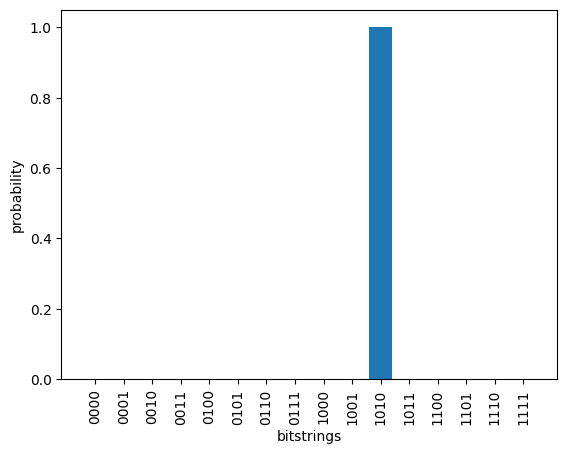

In [7]:
# Test for higher number of qubits. Suppose we want to find '1010'

hidden_string = "1010"

# get Bernstein-Vazirani circuit
circ = bv_circuit(hidden_string)

# print circuit
print(circ)

solution = run_bv_circuit(circ)
print(solution)